In [1]:


import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math, random, time
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")


corpus = """the cat sat on the mat the cat is fat the mat is flat
the dog ran in the park the dog is big the park is green
i love deep learning deep learning is fun learning is great
the sun is bright the sky is blue the weather is nice today
neural networks learn from data data is important for learning
the model trains on batches batches contain many examples
recurrent networks process sequences sequences have order
long short term memory solves vanishing gradients in deep networks
the quick brown fox jumps over the lazy dog
to be or not to be that is the question
all that glitters is not gold the world is full of wonder
learning never exhausts the mind the mind is a powerful thing"""

# ── Tokenisation au niveau mot ───────────────────────────
tokens = corpus.lower().split()
print(f"Nombre de tokens : {len(tokens)}")

# ── Construction du vocabulaire ──────────────────────────
vocab      = sorted(set(tokens))
vocab_size = len(vocab)
word2idx   = {w: i for i, w in enumerate(vocab)}
idx2word   = {i: w for w, i in word2idx.items()}
print(f"Taille du vocabulaire : {vocab_size}")
print(f"Exemples : {vocab[:10]}")

# ── Encodage du corpus en indices ────────────────────────
data_ids = [word2idx[w] for w in tokens]
data_tensor = torch.tensor(data_ids, dtype=torch.long)

# ── Création des séquences (X → Y) ──────────────────────
# Pour chaque fenêtre de seq_len mots,
# on prédit le mot suivant
SEQ_LEN    = 5
BATCH_SIZE = 16

def make_sequences(data, seq_len):
    X, Y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i+seq_len])
        Y.append(data[i+seq_len])
    return torch.stack(X), torch.stack(Y)

X_seq, Y_seq = make_sequences(data_tensor, SEQ_LEN)
print(f"Séquences X : {X_seq.shape} | Labels Y : {Y_seq.shape}")

# ── Split train/test ─────────────────────────────────────
split      = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
Y_train, Y_test = Y_seq[:split], Y_seq[split:]

from torch.utils.data import TensorDataset, DataLoader
train_loader = DataLoader(TensorDataset(X_train, Y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test,  Y_test),
                          batch_size=BATCH_SIZE)
print("Données prêtes ✓")


Device : cpu
Nombre de tokens : 130
Taille du vocabulaire : 77
Exemples : ['a', 'all', 'batches', 'be', 'big', 'blue', 'bright', 'brown', 'cat', 'contain']
Séquences X : torch.Size([125, 5]) | Labels Y : torch.Size([125])
Données prêtes ✓



=== RNN Simple ===
  Epoch  5/30 | Loss: 3.7310 | Perplexité: 41.72
  Epoch 10/30 | Loss: 2.9789 | Perplexité: 19.67
  Epoch 15/30 | Loss: 2.4407 | Perplexité: 11.48
  Epoch 20/30 | Loss: 1.9670 | Perplexité: 7.15
  Epoch 25/30 | Loss: 1.4846 | Perplexité: 4.41
  Epoch 30/30 | Loss: 1.0580 | Perplexité: 2.88

=== LSTM ===
  Epoch  5/30 | Loss: 4.1588 | Perplexité: 64.00
  Epoch 10/30 | Loss: 3.6050 | Perplexité: 36.78
  Epoch 15/30 | Loss: 2.9452 | Perplexité: 19.02
  Epoch 20/30 | Loss: 2.4920 | Perplexité: 12.09
  Epoch 25/30 | Loss: 1.9510 | Perplexité: 7.04
  Epoch 30/30 | Loss: 1.4782 | Perplexité: 4.39

=== GRU ===
  Epoch  5/30 | Loss: 4.0140 | Perplexité: 55.37
  Epoch 10/30 | Loss: 3.3935 | Perplexité: 29.77
  Epoch 15/30 | Loss: 2.8290 | Perplexité: 16.93
  Epoch 20/30 | Loss: 2.2359 | Perplexité: 9.35
  Epoch 25/30 | Loss: 1.7952 | Perplexité: 6.02
  Epoch 30/30 | Loss: 1.3592 | Perplexité: 3.89

=== Perplexité finale ===
RNN  : 2.88
LSTM : 4.39
GRU  : 3.89


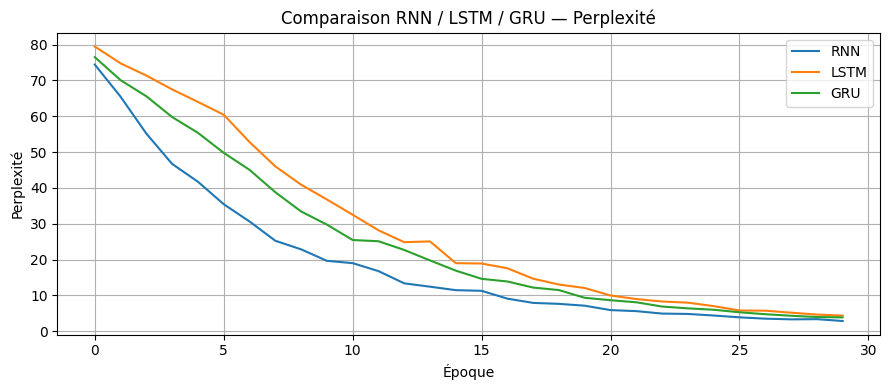

In [2]:

# ============================================================
# MODÈLES RÉCURRENTS : RNN, LSTM, GRU
# ============================================================

class ModelRNN(nn.Module):
    """RNN simple pour prédiction du prochain mot."""
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn       = nn.RNN(embed_dim, hidden_dim,
                                batch_first=True)
        self.fc        = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)           # [B, seq, embed]
        out, _ = self.rnn(emb)            # [B, seq, hidden]
        return self.fc(out[:, -1, :])      # dernier pas de temps


class ModelLSTM(nn.Module):
    """LSTM : gère mieux les dépendances longues grâce aux portes."""
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim,
                                 batch_first=True)
        self.fc        = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, (h, c) = self.lstm(emb)      # h=hidden, c=cell state
        return self.fc(out[:, -1, :])


class ModelGRU(nn.Module):
    """GRU : version allégée du LSTM, souvent aussi performant."""
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru       = nn.GRU(embed_dim, hidden_dim,
                                batch_first=True)
        self.fc        = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.gru(emb)
        return self.fc(out[:, -1, :])


# ── Fonction d'entraînement avec gradient clipping ───────
def train_rnn(model, train_loader, test_loader,
             n_epochs=30, lr=1e-3, clip=1.0):
    """
    clip : gradient clipping pour éviter l'explosion des gradients
    (problème classique en BPTT — rétropropagation dans le temps)
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history   = {"train_loss":[], "perplexity":[]}

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            # Gradient clipping : limite la norme des gradients
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            total_loss += loss.item()

        avg_loss   = total_loss / len(train_loader)
        perplexity = math.exp(avg_loss)        # perplexité = e^loss
        history["train_loss"].append(avg_loss)
        history["perplexity"].append(perplexity)

        if (epoch+1) % 5 == 0:
            print(f"  Epoch {epoch+1:2d}/{n_epochs} | "
                  f"Loss: {avg_loss:.4f} | Perplexité: {perplexity:.2f}")
    return history


# ── Entraînement des 3 modèles ───────────────────────────
print("\n=== RNN Simple ===")
rnn_model  = ModelRNN(vocab_size).to(device)
hist_rnn   = train_rnn(rnn_model,  train_loader, test_loader)

print("\n=== LSTM ===")
lstm_model = ModelLSTM(vocab_size).to(device)
hist_lstm  = train_rnn(lstm_model, train_loader, test_loader)

print("\n=== GRU ===")
gru_model  = ModelGRU(vocab_size).to(device)
hist_gru   = train_rnn(gru_model,  train_loader, test_loader)

# ── Comparaison perplexité ───────────────────────────────
print("\n=== Perplexité finale ===")
print(f"RNN  : {hist_rnn['perplexity'][-1]:.2f}")
print(f"LSTM : {hist_lstm['perplexity'][-1]:.2f}")
print(f"GRU  : {hist_gru['perplexity'][-1]:.2f}")

plt.figure(figsize=(9, 4))
plt.plot(hist_rnn["perplexity"],  label="RNN")
plt.plot(hist_lstm["perplexity"], label="LSTM")
plt.plot(hist_gru["perplexity"],  label="GRU")
plt.title("Comparaison RNN / LSTM / GRU — Perplexité")
plt.xlabel("Époque"); plt.ylabel("Perplexité")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig("comparaison_rnn.png", dpi=150)
plt.show()


In [3]:

# ============================================================
# SEQ2SEQ : Encodeur + Décodeur récurrents
# Tâche : inverser une séquence de mots
# Ex : "the cat sat" → "sat cat the"
# ============================================================

# Tokens spéciaux
SOS_TOKEN = "<sos>"   # Start Of Sequence
EOS_TOKEN = "<eos>"   # End Of Sequence
PAD_TOKEN = "<pad>"   # Padding

# Vocabulaire étendu avec tokens spéciaux
special = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]
vocab_s2s  = special + vocab
vs_size    = len(vocab_s2s)
w2i        = {w: i for i, w in enumerate(vocab_s2s)}
i2w        = {i: w for w, i in w2i.items()}
PAD_IDX    = w2i[PAD_TOKEN]
SOS_IDX    = w2i[SOS_TOKEN]
EOS_IDX    = w2i[EOS_TOKEN]
print(f"Vocab Seq2Seq : {vs_size} mots")

# ── Paires source→cible (inversion de séquence) ──────────
sentences = [line.strip().split()
             for line in corpus.strip().split('\n')
             if len(line.strip().split()) >= 3]
pairs = [(s, s[::-1]) for s in sentences]
print(f"Paires d'entraînement : {len(pairs)}")
print(f"Exemple : {pairs[0][0]} → {pairs[0][1]}")

def encode_seq(seq, w2i, max_len=10):
    ids = [w2i.get(w, PAD_IDX) for w in seq[:max_len]]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

MAX_LEN = 8
src_seqs = torch.tensor([encode_seq(s, w2i, MAX_LEN) for s, t in pairs])
tgt_seqs = torch.tensor([encode_seq(t, w2i, MAX_LEN) for s, t in pairs])

# ── Encodeur ─────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        emb = self.embedding(x)
        _, hidden = self.gru(emb)   # hidden = contexte résumé
        return hidden

# ── Décodeur ─────────────────────────────────────────────
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        emb = self.embedding(x.unsqueeze(1))    # [B,1,embed]
        out, hidden = self.gru(emb, hidden)
        pred = self.fc(out.squeeze(1))           # [B, vocab]
        return pred, hidden

# ── Seq2Seq complet ──────────────────────────────────────
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing=0.5):
        """
        teacher_forcing : prob d'utiliser le vrai token
        comme entrée du décodeur (plutôt que la prédiction)
        """
        B, T     = tgt.shape
        outputs  = torch.zeros(B, T, vs_size).to(device)
        hidden   = self.encoder(src)
        dec_input = torch.full((B,), SOS_IDX,
                               dtype=torch.long).to(device)
        for t in range(T):
            pred, hidden = self.decoder(dec_input, hidden)
            outputs[:, t] = pred
            # Teacher forcing
            use_teacher = random.random() < teacher_forcing
            dec_input   = tgt[:, t] if use_teacher else pred.argmax(1)
        return outputs

encoder   = Encoder(vs_size).to(device)
decoder   = Decoder(vs_size).to(device)
seq2seq   = Seq2Seq(encoder, decoder).to(device)
print(f"Paramètres Seq2Seq : {sum(p.numel() for p in seq2seq.parameters()):,}")


Vocab Seq2Seq : 80 mots
Paires d'entraînement : 12
Exemple : ['the', 'cat', 'sat', 'on', 'the', 'mat', 'the', 'cat', 'is', 'fat', 'the', 'mat', 'is', 'flat'] → ['flat', 'is', 'mat', 'the', 'fat', 'is', 'cat', 'the', 'mat', 'the', 'on', 'sat', 'cat', 'the']
Paramètres Seq2Seq : 47,952


In [4]:
# ── Entraînement Seq2Seq ─────────────────────────────────
criterion_s2s = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer_s2s = optim.Adam(seq2seq.parameters(), lr=1e-3)
s2s_loader    = DataLoader(TensorDataset(src_seqs, tgt_seqs),
                           batch_size=4, shuffle=True)
hist_s2s = []

print("\n=== Entraînement Seq2Seq ===")
for epoch in range(50):
    seq2seq.train()
    total = 0
    for src, tgt in s2s_loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer_s2s.zero_grad()
        output = seq2seq(src, tgt)           # [B, T, vocab]
        loss   = criterion_s2s(
            output.view(-1, vs_size), tgt.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(seq2seq.parameters(), 1.0)
        optimizer_s2s.step()
        total += loss.item()
    avg = total / len(s2s_loader)
    hist_s2s.append(avg)
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1:2d}/50 | Loss: {avg:.4f} | Perplexité: {math.exp(avg):.2f}")

# ── Décodage Glouton (Greedy) ────────────────────────────
def greedy_decode(model, src_sentence, max_len=8):
    """Prend toujours le token avec la plus haute probabilité."""
    model.eval()
    src_ids = torch.tensor([encode_seq(src_sentence, w2i, MAX_LEN)]).to(device)
    hidden  = model.encoder(src_ids)
    token   = torch.tensor([SOS_IDX]).to(device)
    result  = []
    with torch.no_grad():
        for _ in range(max_len):
            pred, hidden = model.decoder(token, hidden)
            token = pred.argmax(1)
            word  = i2w[token.item()]
            if word in [EOS_TOKEN, PAD_TOKEN]:
                break
            result.append(word)
    return result

# ── Beam Search ──────────────────────────────────────────
def beam_search_decode(model, src_sentence, beam_width=3, max_len=8):
    """
    Explore les beam_width meilleures séquences à chaque pas.
    Plus rigoureux que le décodage glouton.
    """
    model.eval()
    src_ids = torch.tensor([encode_seq(src_sentence, w2i, MAX_LEN)]).to(device)
    hidden  = model.encoder(src_ids)
    # Chaque faisceau : (score_log, séquence, hidden)
    beams   = [(0.0, [SOS_IDX], hidden)]

    with torch.no_grad():
        for _ in range(max_len):
            candidates = []
            for score, seq, hid in beams:
                token = torch.tensor([seq[-1]]).to(device)
                pred, new_hid = model.decoder(token, hid)
                log_probs = torch.log_softmax(pred, dim=-1).squeeze()
                top_vals, top_ids = log_probs.topk(beam_width)
                for val, idx in zip(top_vals, top_ids):
                    candidates.append(
                        (score + val.item(), seq + [idx.item()], new_hid))
            beams = sorted(candidates, key=lambda x: x[0],
                           reverse=True)[:beam_width]

    best_seq = beams[0][1][1:]  # enlever SOS
    return [i2w[i] for i in best_seq
            if i2w[i] not in [EOS_TOKEN, PAD_TOKEN, SOS_TOKEN]]

# ── Tests de décodage ────────────────────────────────────
test_sentences = [
    ["the", "cat", "sat"],
    ["the", "dog", "ran"],
    ["deep", "learning", "is"],
]
print("\n=== Comparaison Greedy vs Beam Search ===")
print(f"{'Source':<25} {'Cible attendue':<25} {'Greedy':<25} {'Beam Search'}")
print("-"*95)
for s in test_sentences:
    target  = s[::-1]
    greedy  = greedy_decode(seq2seq, s)
    beam    = beam_search_decode(seq2seq, s)
    print(f"{' '.join(s):<25} {' '.join(target):<25} {' '.join(greedy):<25} {' '.join(beam)}")


=== Entraînement Seq2Seq ===
  Epoch 10/50 | Loss: 4.0326 | Perplexité: 56.41
  Epoch 20/50 | Loss: 3.4603 | Perplexité: 31.83
  Epoch 30/50 | Loss: 2.9113 | Perplexité: 18.38
  Epoch 40/50 | Loss: 2.3411 | Perplexité: 10.39
  Epoch 50/50 | Loss: 1.7800 | Perplexité: 5.93

=== Comparaison Greedy vs Beam Search ===
Source                    Cible attendue            Greedy                    Beam Search
-----------------------------------------------------------------------------------------------
the cat sat               sat cat the               flat is is the the the the the flat is is the the the the the
the dog ran               ran dog the               flat is is the the the the the flat is is the the the the the
deep learning is          is learning deep          today is is the the the the the flat is is the the the the the


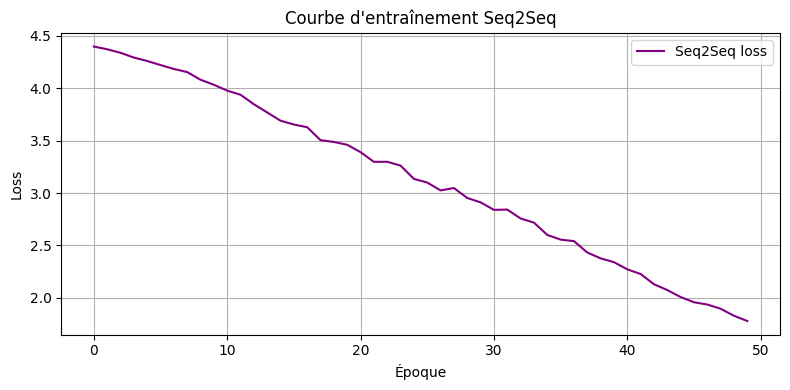

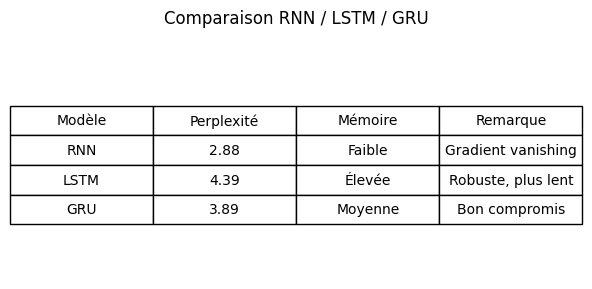


PARTIE III TERMINEE
Fichiers générés :
  - comparaison_rnn.png   → courbes perplexité RNN/LSTM/GRU
  - seq2seq_loss.png      → courbe loss Seq2Seq
  - tableau_comparaison.png → tableau récapitulatif


In [5]:

# ── Courbe loss Seq2Seq ──────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(hist_s2s, label="Seq2Seq loss", color="purple")
plt.title("Courbe d'entraînement Seq2Seq")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig("seq2seq_loss.png", dpi=150)
plt.show()

# ── Tableau récap perplexités ────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis("off")
data_table = [
    ["RNN",  f"{hist_rnn['perplexity'][-1]:.2f}",
     "Faible", "Gradient vanishing"],
    ["LSTM", f"{hist_lstm['perplexity'][-1]:.2f}",
     "Élevée", "Robuste, plus lent"],
    ["GRU",  f"{hist_gru['perplexity'][-1]:.2f}",
     "Moyenne", "Bon compromis"],
]
table = ax.table(
    cellText=data_table,
    colLabels=["Modèle", "Perplexité", "Mémoire", "Remarque"],
    loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
plt.title("Comparaison RNN / LSTM / GRU", pad=20)
plt.tight_layout()
plt.savefig("tableau_comparaison.png", dpi=150)
plt.show()

print("""
============================================================
PARTIE III TERMINEE
Fichiers générés :
  - comparaison_rnn.png   → courbes perplexité RNN/LSTM/GRU
  - seq2seq_loss.png      → courbe loss Seq2Seq
  - tableau_comparaison.png → tableau récapitulatif
============================================================""")
